In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

df = pd.read_csv("../data/li-data.csv", sep=";", header=0)

/var/folders/9f/7hhtd_4d75sc0w7x26jq14hh0000gn/T/ipykernel_16391/4064475813.py:8: DtypeWarning: Columns (60) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/li-data.csv", sep=";", header=0)


In [3]:
legend_col = df.columns[-1]
df = df.drop(columns=[legend_col])
df

,SOC_C_3300,P_AC_C_3300,C_C_3300,V_C_3300,Ta_C_3300,SOC_C_2700,P_AC_C_2700,C_C_2700,V_C_2700,_C_2700,...,SOC_D_660,P_AC_D_660,C_D_660,V_D_660,Ta_D_660,SOC_D_330,P_AC_D_330,C_D_330,V_D_330,Ta_D_330
0,20.0,-3272.0,-57.41,50.55,15.45,20.0,-2768.0,-51.803070,50.761470,22.245,...,91.0,679.0,12.98,56.16,22.15,91.0,377.0,6.70,57.02,18.326
1,20.0,-3276.0,-57.56,50.59,15.44,20.0,-2700.0,-50.492061,50.800065,22.238,...,91.0,679.0,12.33,56.16,22.19,91.0,363.0,6.72,57.01,18.329
2,20.0,-3273.0,-57.27,50.63,15.43,20.0,-2700.0,-50.448033,50.844401,22.250,...,90.0,680.0,12.33,56.15,22.23,90.0,365.0,6.67,57.01,18.338
3,21.0,-3273.0,-57.56,50.66,15.40,20.0,-2702.0,-50.454699,50.875341,22.267,...,90.0,680.0,12.35,56.15,22.25,90.0,365.0,6.59,57.01,18.342
4,21.0,-3273.0,-57.27,50.69,15.41,20.0,-2702.0,-50.432881,50.897350,22.254,...,90.0,680.0,12.35,56.14,22.23,90.0,363.0,6.69,57.00,18.346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
last_col_c = "_C_2700"
last_col_d = "_D_2700"

df = df.rename(columns={last_col_c: "Ta_C_2700", last_col_d: "Ta_D_2700"})
df

,SOC_C_3300,P_AC_C_3300,C_C_3300,V_C_3300,Ta_C_3300,SOC_C_2700,P_AC_C_2700,C_C_2700,V_C_2700,Ta_C_2700,...,SOC_D_660,P_AC_D_660,C_D_660,V_D_660,Ta_D_660,SOC_D_330,P_AC_D_330,C_D_330,V_D_330,Ta_D_330
0,20.0,-3272.0,-57.41,50.55,15.45,20.0,-2768.0,-51.803070,50.761470,22.245,...,91.0,679.0,12.98,56.16,22.15,91.0,377.0,6.70,57.02,18.326
1,20.0,-3276.0,-57.56,50.59,15.44,20.0,-2700.0,-50.492061,50.800065,22.238,...,91.0,679.0,12.33,56.16,22.19,91.0,363.0,6.72,57.01,18.329
2,20.0,-3273.0,-57.27,50.63,15.43,20.0,-2700.0,-50.448033,50.844401,22.250,...,90.0,680.0,12.33,56.15,22.23,90.0,365.0,6.67,57.01,18.338
3,21.0,-3273.0,-57.56,50.66,15.40,20.0,-2702.0,-50.454699,50.875341,22.267,...,90.0,680.0,12.35,56.15,22.25,90.0,365.0,6.59,57.01,18.342
4,21.0,-3273.0,-57.27,50.69,15.41,20.0,-2702.0,-50.432881,50.897350,22.254,...,90.0,680.0,12.35,56.14,22.23,90.0,363.0,6.69,57.00,18.346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19965,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19968,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
power_levels = [3300, 2700, 1650, 1000, 660, 330]
modes = {"C": 0, "D": 1}

records = []
for mode, mode_flag in modes.items():
    for p in power_levels:
        soc_col = f"SOC_{mode}_{p}"
        pac_col = f"P_AC_{mode}_{p}"
        c_col   = f"C_{mode}_{p}"
        v_col   = f"V_{mode}_{p}"
        ta_col  = f"Ta_{mode}_{p}"
        subset = df[[soc_col, pac_col, c_col, v_col, ta_col]].copy()
        subset.columns = ["SOC", "P_AC", "C", "V", "Ta"]
        subset["power_level"] = p
        subset["mode"] = mode_flag
        records.append(subset)



In [6]:
data = pd.concat(records, ignore_index=True)
data = data.dropna()
data

,SOC,P_AC,C,V,Ta,power_level,mode
0,20.0,-3272.0,-57.41,50.55,15.450,3300,0
1,20.0,-3276.0,-57.56,50.59,15.440,3300,0
2,20.0,-3273.0,-57.27,50.63,15.430,3300,0
3,21.0,-3273.0,-57.56,50.66,15.400,3300,0
4,21.0,-3273.0,-57.27,50.69,15.410,3300,0
...,...,...,...,...,...,...,...
233226,21.0,360.0,7.51,50.31,1691.753,330,1
233227,21.0,362.0,7.50,50.31,1692.753,330,1
233228,21.0,362.0,7.52,50.31,1693.753,330,1
233229,21.0,362.0,7.45,50.31,1694.753,330,1


In [7]:
X = data[["P_AC", "C", "V", "Ta", "power_level", "mode"]]
y = data["SOC"]
X.shape, y.shape

((67630, 6), (67630,))

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape

((54104, 6), (54104,))

In [9]:
model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:

y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"r2: {r2} mae: {mae} rmse: {rmse}")

r2: 0.9996490257737822 mae: 0.24722420843187282 rmse: 0.37685948583013995


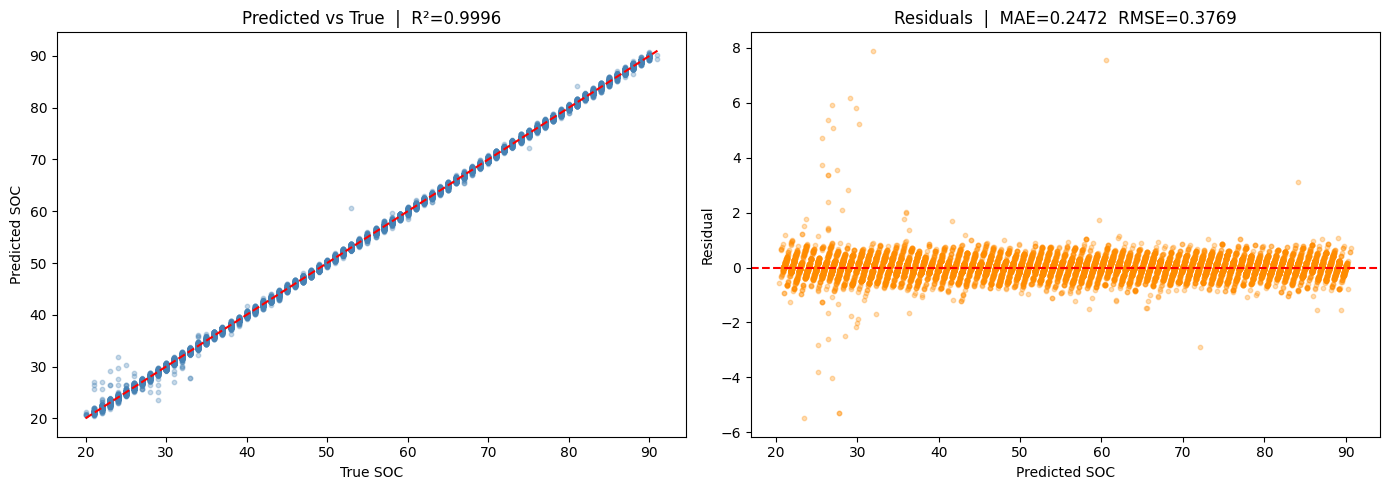

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color="steelblue")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5)
axes[0].set_xlabel("True SOC")
axes[0].set_ylabel("Predicted SOC")
axes[0].set_title(f"Predicted vs True  |  R²={r2:.4f}")

residuals = y_pred - y_test.values
axes[1].scatter(y_pred, residuals, alpha=0.3, s=10, color="darkorange")
axes[1].axhline(0, color="red", linewidth=1.5, linestyle="--")
axes[1].set_xlabel("Predicted SOC")
axes[1].set_ylabel("Residual")
axes[1].set_title(f"Residuals  |  MAE={mae:.4f}  RMSE={rmse:.4f}")

plt.tight_layout()
plt.savefig("soc_xgb_results.png", dpi=150)
plt.show()